In [1]:
import re
import shutil
import time
import pandas as pd
import statistics as stat
import numpy as np
import cmdstanpy as csp
import warnings
import logging
from numpy import random
import os
import time
from sklearn.metrics import accuracy_score, roc_auc_score, root_mean_squared_error

csp.utils.get_logger().setLevel(logging.ERROR)

/home/sppradhan/Desktop/Research/StanBKT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def sim_simple_BKT(
    rng=np.random.default_rng(0),
    nStudents: int = 10,
    nProblems: int = 20,
    nKcs: int = 1,
    prior=0.1,
    learn=0.01,
    forget=0.05,
    guess=0.2,
    slip=0.1,
    kc_sequence=None,
):

    def _param_to_vec(x, name):
        arr = np.asarray(x, dtype=float)
        if arr.size == 1:
            arr = np.repeat(arr, nKcs)
        if arr.size != nKcs:
            raise ValueError(f"{name} must be scalar or length nKcs")
        return arr

    prior_vec = _param_to_vec(prior, "prior")
    learn_vec = _param_to_vec(learn, "learn")
    forget_vec = _param_to_vec(forget, "forget")
    guess_vec = _param_to_vec(guess, "guess")
    slip_vec = _param_to_vec(slip, "slip")

    # KC for each problem

    if kc_sequence is None:
        kc_sequence = rng.integers(0, nKcs, size=nProblems)
    else:
        kc_sequence = np.asarray(kc_sequence, dtype=int)
        if kc_sequence.shape[0] != nProblems:
            raise ValueError("kc_sequence must have length nProblems")
        if kc_sequence.min() < 0 or kc_sequence.max() >= nKcs:
            raise ValueError("kc_sequence entries must be in [0, nKcs-1]")

    # Initial knowledge state per (student, KC)
    knowledge = rng.random(size=(nStudents, nKcs)) < prior_vec
    correctness = np.zeros((nStudents, nProblems), dtype=int)
    states = np.zeros((nStudents, nProblems), dtype=int)

    for t in range(nProblems):
        kc = kc_sequence[t]
        for s in range(nStudents):
            knows_before = knowledge[s, kc]
            # Generate response

            if knows_before:
                # Slip with prob slip_vec[kc]
                correct = int(rng.random() >= slip_vec[kc])
            else:
                # Guess with prob guess_vec[kc]
                correct = int(rng.random() < guess_vec[kc])

            correctness[s, t] = correct

            # Update knowledge state for this KC (BKT transition)

            if knows_before:
                knowledge[s, kc] = rng.random() >= forget_vec[kc]
            else:
                # May learn
                knowledge[s, kc] = rng.random() < learn_vec[kc]
            # Record full KC vector after this problem
            states[s, t] = knowledge[s, kc]

    return (
        correctness,
        states,
        kc_sequence,
        nStudents,
        nProblems,
        nKcs,
    )

In [3]:
def sort_by_kc(correctness, states, kc_sequence, n_kcs):
    """Group correctness and states by KC, preserving original problem order.

    correctness : (n_students, n_problems)
    states      : (n_students, n_problems)
    kc_sequence : (n_problems,), values in [0, n_kcs-1]
    n_kcs      : int or None (inferred from kc_sequence if None)
    Returns lists correctness_by_kc, states_by_kc, kc_indices.
    """
    correctness = np.asarray(correctness)
    kc_sequence = np.asarray(kc_sequence, dtype=int)
    states_arr = np.asarray(states)

    n_students, n_problems = correctness.shape

    if kc_sequence.shape[0] != n_problems:
        raise ValueError("kc_sequence must have length n_problems")
    correctness_by_kc: list[np.ndarray] = []
    states_by_kc: list[np.ndarray] = []
    kc_indices: list[np.ndarray] = []

    for kc in range(n_kcs):
        idx = np.nonzero(kc_sequence == kc)[0]
        kc_indices.append(idx)
        correctness_by_kc.append(correctness[:, idx])
        states_by_kc.append(states_arr[:, idx])
    return correctness_by_kc, states_by_kc, kc_indices

In [4]:
(
    correctness,
    states,
    kc_sequence,
    n_students,
    n_problems,
    n_kcs,
) = sim_simple_BKT(
    rng=np.random.default_rng(123),
    nStudents=30,
    nProblems=20,
    nKcs=1,
    prior=0.4,
    learn=0.04,
    forget=0.01,
    guess=0.2,
    slip=0.1,
    kc_sequence=None,
)

In [5]:
rng = np.random.default_rng(123)

In [6]:
correctness_by_kc, states_by_kc, kc_indices = sort_by_kc(
    correctness, states, kc_sequence, n_kcs
)

In [7]:
import pickle

data_dict = {
    "nStudents": n_students,
    "nProblems": n_problems,
    "correctness": correctness,
    "nGroups": 1,
    "groups": [1] * n_students,  # single group they are in the same group
    "states": states,
}
pickle.dump(data_dict, open("data_dict.pkl", "wb"))

In [8]:
start_time = time.perf_counter()

In [9]:
print("Compiling Stan model...")
model = csp.CmdStanModel(
    stan_file="./src/stanbkt/stan_code/BKT/BKT_model.stan",
    cpp_options={"STAN_THREADS": "true"},
)

Compiling Stan model...


In [10]:
print("+-" * 20)
start_time = time.perf_counter()
print("Sampling...")
fits = {}
print("Training new model...")
for kc_idx in range(len(correctness_by_kc)):
    print("Fitting KC", kc_idx)
    correctness = correctness_by_kc[kc_idx]
    n_students, n_problems = correctness.shape
    data_dict = {
        "nStudents": n_students,
        "nProblems": n_problems,
        "correctness": correctness,
        "nGroups": 1,
        "groups": [1] * n_students,  # single group they are in the same group
    }
    fit = model.sample(
        data=data_dict,
        seed=[1, 2, 3, 4],
        chains=4,
        threads_per_chain=4,
        parallel_chains=4,
        iter_sampling=1500,
        iter_warmup=2000,
        thin=2,
        show_progress="notebook",
        # show_console=True
    )
    fits[kc_idx] = fit

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Sampling...
Training new model...
Fitting KC 0


chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   3%|▎         | 100/3500 [00:00<00:04, 747.77it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:00<00:04, 766.42it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:00<00:04, 789.18it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:00<00:03, 955.17it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:00<00:03, 950.41it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:00<00:02, 1034.87it/s, (Warmup)]


chain 1:  29%|██▊       | 1000/3500 [00:01<00:02, 984.15it/s, (Warmup)]


chain 1:  31%|███▏      | 1100/3500 [00:01<00:02, 958.42it/s, (Warmup)]


chain 1:  37%|███▋      | 1300/3500 [00:01<00:02, 1035.40it/s, (Warmup)]


chain 1:  43%|████▎     | 1500/3500 [00:01<00:01, 1058.17it/s, (Warmup)]



chain 1:  49%|████▊     | 1700/3500 [00:01<00:01, 1042.42it/s, (Warmup)]




chain 1:  54%|█████▍    | 1900/3500 [00:01<00:01, 1062.55it/s, (Warmup)]


chain 1:  57%|█████▋    | 2000/3500 [00:02<00:01, 1062.55it/s, (Sampling)]


chain 1:  60%|██████    | 210

In [11]:
indexes = ["pi_know[1]", "learn[1]", "forget[1]", "guess[1]", "slip[1]"]

In [12]:
summary = fits[0].summary()

In [13]:
summary.loc[indexes, "Mean"].values

array([0.471798  , 0.0263059 , 0.00498723, 0.164333  , 0.116919  ])

In [14]:
print(summary.loc[summary.index.str.startswith("pKnow[1,"), "Mean"].values)

[]


In [15]:
print(summary.loc[summary.index.str.startswith("pCorrectness[1,"), "Mean"].values)

[]


In [16]:
correctness_flat = correctness.flatten()
states_flat = states.flatten()
know_probs_flat = summary.loc[
    summary.index.str.startswith("know_probs["),
    "Mean",
].values

In [17]:
hidden_state_smoothed_mod = csp.CmdStanModel(
    stan_file="./src/stanbkt/stan_code/BKT/smoothed_hidden_states.stan",
    cpp_options={"STAN_THREADS": "true"},
)

In [18]:
test = hidden_state_smoothed_mod.sample(
        data=data_dict,
        seed=[1, 2, 3, 4],
        chains=4,
        threads_per_chain=4,
        parallel_chains=4,
        iter_sampling=1500,
        iter_warmup=2000,
        thin=2,
        show_progress="notebook",
        # show_console=True
    )

chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 2:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   3%|▎         | 100/3500 [00:00<00:04, 698.51it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:00<00:04, 781.40it/s, (Warmup)]




chain 1:  14%|█▍        | 500/3500 [00:00<00:03, 904.02it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:00<00:03, 822.76it/s, (Warmup)]

chain 1:  23%|██▎       | 800/3500 [00:00<00:03, 800.52it/s, (Warmup)]

chain 1:  26%|██▌       | 900/3500 [00:01<00:03, 795.99it/s, (Warmup)]


chain 1:  31%|███▏      | 1100/3500 [00:01<00:02, 918.60it/s, (Warmup)]


chain 1:  37%|███▋      | 1300/3500 [00:01<00:02, 1057.53it/s, (Warmup)]


chain 1:  43%|████▎     | 1500/3500 [00:01<00:01, 1137.38it/s, (Warmup)]


chain 1:  49%|████▊     | 1700/3500 [00:01<00:01, 1217.32it/s, (Warmup)]

chain 1:  54%|█████▍    | 1900/3500 [00:01<00:01, 1295.61it/s, (Warmup)]


chain 1:  57%|█████▋    | 2000/3500 [00:01<00:01, 1295.61it/s, (Sampling)]


chain 1:  60%|██████    | 2100/3500 [00:02<00:01, 

In [19]:
gq_fit = hidden_state_smoothed_mod.generate_quantities(
    data=data_dict, previous_fit=fits[0]
)

In [20]:
gq_fit.draws_pd()

,chain__,iter__,draw__,"know_probs[1,1]","know_probs[2,1]","know_probs[3,1]","know_probs[4,1]","know_probs[5,1]","know_probs[6,1]","know_probs[7,1]",...,"know_probs[21,20]","know_probs[22,20]","know_probs[23,20]","know_probs[24,20]","know_probs[25,20]","know_probs[26,20]","know_probs[27,20]","know_probs[28,20]","know_probs[29,20]","know_probs[30,20]"
0,1.0,1.0,1.0,0.001474,0.989627,0.989631,0.990232,0.990233,0.821854,0.000298,...,0.999239,0.999239,0.141738,0.999239,0.993173,0.009794,0.003812,0.999239,0.136836,0.003846
1,1.0,2.0,2.0,0.007230,0.992169,0.992169,0.992302,0.992302,0.907130,0.001066,...,0.998947,0.998947,0.307428,0.998947,0.992264,0.034558,0.007603,0.998947,0.264253,0.007791
2,1.0,3.0,3.0,0.003196,0.993430,0.993430,0.993581,0.993581,0.902181,0.000271,...,0.999443,0.999443,0.152170,0.999443,0.995307,0.015261,0.003088,0.999443,0.138166,0.003135
3,1.0,4.0,4.0,0.004454,0.991763,0.991768,0.992314,0.992314,0.866729,0.001558,...,0.997165,0.997165,0.133523,0.997165,0.976937,0.009284,0.004188,0.997165,0.128252,0.004232
4,1.0,5.0,5.0,0.001847,0.989263,0.989270,0.990002,0.990002,0.813703,0.000583,...,0.996710,0.996710,0.066803,0.996710,0.971077,0.003840,0.001765,0.996710,0.064633,0.001780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,4.0,746.0,2996.0,0.007286,0.995553,0.995553,0.995684,0.995684,0.936857,0.000619,...,0.999248,0.999248,0.142508,0.999248,0.994166,0.017647,0.003489,0.999248,0.128726,0.003550
2996,4.0,747.0,2997.0,0.011834,0.988833,0.988835,0.989303,0.989303,0.891975,0.000307,...,0.999433,0.999433,0.145982,0.999433,0.996641,0.082025,0.005640,0.999433,0.123118,0.005830
2997,4.0,748.0,2998.0,0.010654,0.993728,0.993728,0.993940,0.993940,0.927361,0.000213,...,0.999658,0.999658,0.123079,0.999658,0.997712,0.061481,0.003688,0.999658,0.106255,0.003784
2998,4.0,749.0,2999.0,0.002144,0.980219,0.980222,0.981106,0.981106,0.747899,0.000644,...,0.997788,0.997788,0.184276,0.997788,0.982519,0.014094,0.005494,0.997788,0.173788,0.005568


In [21]:
gq_df = gq_fit.draws_pd().T

In [22]:
def summarize_df(gq_df):
    mask = ~gq_df.index.to_series().str.startswith(("chain__", "iter__", "draw__"))
    gq_df_clean = gq_df[mask]

    gq_summary = pd.DataFrame({
        "mean": gq_df_clean.mean(axis=1),
        "std": gq_df_clean.std(axis=1),
        "median": gq_df_clean.median(axis=1),
        "2.5%": gq_df_clean.quantile(0.025, axis=1),
        "97.5%": gq_df_clean.quantile(0.975, axis=1),
    })

    idx_nums = gq_summary.index.to_series().str.extract(r"(\d+),(\d+)").astype(int)
    order = np.lexsort((idx_nums[1].values, idx_nums[0].values))
    gq_summary = gq_summary.iloc[order]
    return gq_summary

In [23]:
gq_summary = summarize_df(gq_df)

In [24]:
stu_idx = 15


In [25]:
 
gq_summary.loc[gq_summary.index.str.contains(f"\[{stu_idx+1},")]

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_236817/83342094.py:1: SyntaxWarning: invalid escape sequence '\['
  gq_summary.loc[gq_summary.index.str.contains(f"\[{stu_idx+1},")]


,mean,std,median,2.5%,97.5%
"know_probs[16,1]",0.000816,0.000916,0.000529,0.000020,0.003252
"know_probs[16,2]",0.000144,0.000161,0.000095,0.000005,0.000577
"know_probs[16,3]",0.000047,0.000052,0.000031,0.000003,0.000184
"know_probs[16,4]",0.000039,0.000039,0.000027,0.000004,0.000147
"know_probs[16,5]",0.000075,0.000059,0.000059,0.000012,0.000223
"know_probs[16,6]",0.000317,0.000218,0.000261,0.000066,0.000882
"know_probs[16,7]",0.001890,0.001043,0.001673,0.000516,0.004532
"know_probs[16,8]",0.012319,0.004906,0.011635,0.004857,0.023591
"know_probs[16,9]",0.083120,0.021309,0.082264,0.045221,0.127353
"know_probs[16,10]",0.575800,0.088705,0.580574,0.394589,0.740672


In [26]:
print("correct", correctness_by_kc[0][stu_idx])
print("states ", states_by_kc[0][stu_idx])

correct [0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1]
states  [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [27]:
hidden_states_mod = csp.CmdStanModel(
    stan_file="./src/stanbkt/stan_code/BKT/hidden_states.stan",
    cpp_options={"STAN_THREADS": "true"})

In [28]:
gq_fit_non = hidden_states_mod.generate_quantities(
    data=data_dict, previous_fit=fits[0]
)

In [29]:
gq_fit_non_df = summarize_df(gq_fit_non.draws_pd().T)

In [30]:
gq_fit_non_df.loc[gq_fit_non_df.index.str.contains(f"w\[{stu_idx+1},")]

<>:1: SyntaxWarning: invalid escape sequence '\['
<>:1: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_236817/2597930977.py:1: SyntaxWarning: invalid escape sequence '\['
  gq_fit_non_df.loc[gq_fit_non_df.index.str.contains(f"w\[{stu_idx+1},")]


,mean,std,median,2.5%,97.5%
"pKnow[16,1]",0.471798,0.098251,0.472662,0.284035,0.669967
"pKnow[16,2]",0.139865,0.045415,0.133834,0.073377,0.248052
"pKnow[16,3]",0.048725,0.016310,0.046741,0.022631,0.086592
"pKnow[16,4]",0.033358,0.013937,0.031519,0.011830,0.065575
"pKnow[16,5]",0.030992,0.013946,0.029140,0.009406,0.063806
"pKnow[16,6]",0.030626,0.013959,0.028791,0.009085,0.063621
"pKnow[16,7]",0.030569,0.013960,0.028723,0.009007,0.063593
"pKnow[16,8]",0.030559,0.013961,0.028720,0.009007,0.063588
"pKnow[16,9]",0.030558,0.013961,0.028720,0.009007,0.063588
"pKnow[16,10]",0.030558,0.013961,0.028720,0.009007,0.063588


In [31]:
test.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-283.470000,0.038138,1.710180,1.486310,-286.796000,-283.095000,-281.401000,2202.15,2347.60,1.00048
logit_pi_know_group[1],-0.141028,0.007437,0.399485,0.389717,-0.804641,-0.140154,0.507474,2892.44,2531.37,1.00015
logit_learn_group[1],-3.697400,0.009670,0.501424,0.476656,-4.595840,-3.649550,-2.963010,2704.42,2532.44,1.00095
logit_forget_group[1],-5.789450,0.032421,1.290280,1.068980,-8.080120,-5.561470,-4.206380,2132.82,1912.22,1.00207
logit_guess_group[1],-0.720730,0.004333,0.226899,0.227042,-1.087950,-0.719199,-0.335019,2772.38,2418.58,1.00003
...,...,...,...,...,...,...,...,...,...,...
"know_probs[30,16]",0.001263,0.000028,0.001515,0.000755,0.000107,0.000768,0.004076,2788.53,2295.55,1.00172
"know_probs[30,17]",0.000293,0.000005,0.000289,0.000164,0.000045,0.000206,0.000820,2855.12,2691.11,1.00260
"know_probs[30,18]",0.000240,0.000004,0.000192,0.000132,0.000050,0.000190,0.000599,2733.52,2775.88,1.00227
"know_probs[30,19]",0.000785,0.000010,0.000501,0.000394,0.000219,0.000672,0.001743,2697.53,2650.11,1.00156


In [32]:
end_time = time.perf_counter()
print(f"Total time: {end_time - start_time:.2f} seconds")

Total time: 9.66 seconds


In [33]:
gq_summary.sort_index()

,mean,std,median,2.5%,97.5%
"know_probs[1,10]",0.981698,0.006757,0.982635,0.965700,0.992188
"know_probs[1,11]",0.996449,0.001855,0.996832,0.991748,0.998946
"know_probs[1,12]",0.999264,0.000499,0.999393,0.997931,0.999842
"know_probs[1,13]",0.999811,0.000154,0.999855,0.999394,0.999968
"know_probs[1,14]",0.999910,0.000088,0.999937,0.999677,0.999990
...,...,...,...,...,...
"know_probs[9,5]",0.999563,0.000393,0.999676,0.998544,0.999942
"know_probs[9,6]",0.999884,0.000112,0.999916,0.999588,0.999987
"know_probs[9,7]",0.999946,0.000058,0.999963,0.999801,0.999996
"know_probs[9,8]",0.999958,0.000050,0.999973,0.999829,0.999998


## Import tests

In [34]:
from importlib.resources import files

stan_file = files("stanbkt").joinpath("stan_code/BKT/BKT_model.stan")

model = csp.CmdStanModel(
    stan_file=str(stan_file),
    cpp_options={"STAN_THREADS": "true"},
)

In [35]:
the_fit = model.variational(data=data_dict, seed=1, draws=6969)

In [36]:
vb_dict = the_fit.stan_variables(mean=False)

#### Variational Result Test

In [37]:
for name, values in vb_dict.items():
    vb_dict[name] = values.squeeze(-1)

In [38]:
vb_df = pd.DataFrame(vb_dict)

In [39]:
vb_df.agg(["mean", "std", "median", lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)]).T

,mean,std,median,<lambda>,<lambda>
logit_pi_know_group,-0.191864,0.377262,-0.185609,-0.938219,0.539598
logit_learn_group,-3.623567,0.441661,-3.621930,-4.501006,-2.762708
logit_forget_group,-5.689082,1.044824,-5.696550,-7.682840,-3.602690
logit_guess_group,-0.643287,0.221505,-0.643275,-1.068282,-0.215313
logit_slip_group,-1.189007,0.212502,-1.186980,-1.615522,-0.771978
pi_know,0.453817,0.090427,0.453731,0.281260,0.631719
learn,0.028398,0.012504,0.026035,0.010976,0.059373
forget,0.005776,0.007731,0.003346,0.000460,0.026527
guess,0.173096,0.024831,0.172253,0.127866,0.223189
slip,0.117782,0.019017,0.116900,0.082912,0.158026


In [40]:
gq_fit_non_vb = hidden_states_mod.generate_quantities(
    data=data_dict, previous_fit=the_fit
)

In [41]:
gq_fit_non_vb_df = summarize_df(gq_fit_non_vb.draws_pd().T)

In [42]:
gq_fit_non_vb_df

,mean,std,median,2.5%,97.5%
"pKnow[1,1]",0.453817,0.090427,0.453731,0.281260,0.631719
"pCorrectness[1,1]",0.494896,0.066293,0.495682,0.366335,0.623841
"pKnow[1,2]",0.134837,0.040716,0.129734,0.071456,0.227927
"pCorrectness[1,2]",0.268353,0.036388,0.266406,0.202234,0.345326
"pKnow[1,3]",0.050082,0.017172,0.047501,0.024283,0.090951
...,...,...,...,...,...
"pCorrectness[30,18]",0.213142,0.028127,0.211752,0.161830,0.272363
"pKnow[30,19]",0.036724,0.016460,0.033542,0.013967,0.077486
"pCorrectness[30,19]",0.199097,0.026528,0.197925,0.150038,0.253847
"pKnow[30,20]",0.033676,0.014932,0.030862,0.012971,0.070294


## arviz integration

In [43]:
import arviz as az

In [44]:
data_dict

{'nStudents': 30,
 'nProblems': 20,
 'correctness': array([[0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
        [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [46]:
cmdstanpy_data = az.from_cmdstanpy(
    posterior=fits[0],
    observed_data={"correctness": data_dict['correctness']},
    coords={
            "student": np.arange(data_dict['nStudents']),
            "problem": np.arange(data_dict['nProblems']),
            "group": np.arange(data_dict['nGroups'])
            },
    dims={
        "groups": ["student"],
        "correctness": ["student", "problem"],
        "logit_pi_know_group" : ["group"],
        "logit_learn_group" : ["group"],
        "logit_forget_group" : ["group"],
        "logit_guess_group" : ["group"],
        "logit_slip_group" : ["group"],
        "pi_know": ["group"],
        "learn": ["group"],
        "forget": ["group"],
        "guess": ["group"],
        "slip": ["group"],
    },
)
cmdstanpy_data

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [83]:
cmdstanpy_data.to_dataframe()[[('posterior', 'forget[0]', 0)]]

,"(posterior, forget[0], 0)"
0,0.002996
1,0.006221
2,0.003167
3,0.010126
4,0.012253
...,...
2995,0.003736
2996,0.002110
2997,0.001496
2998,0.009151


In [ ]:
cmdstanpy_data

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

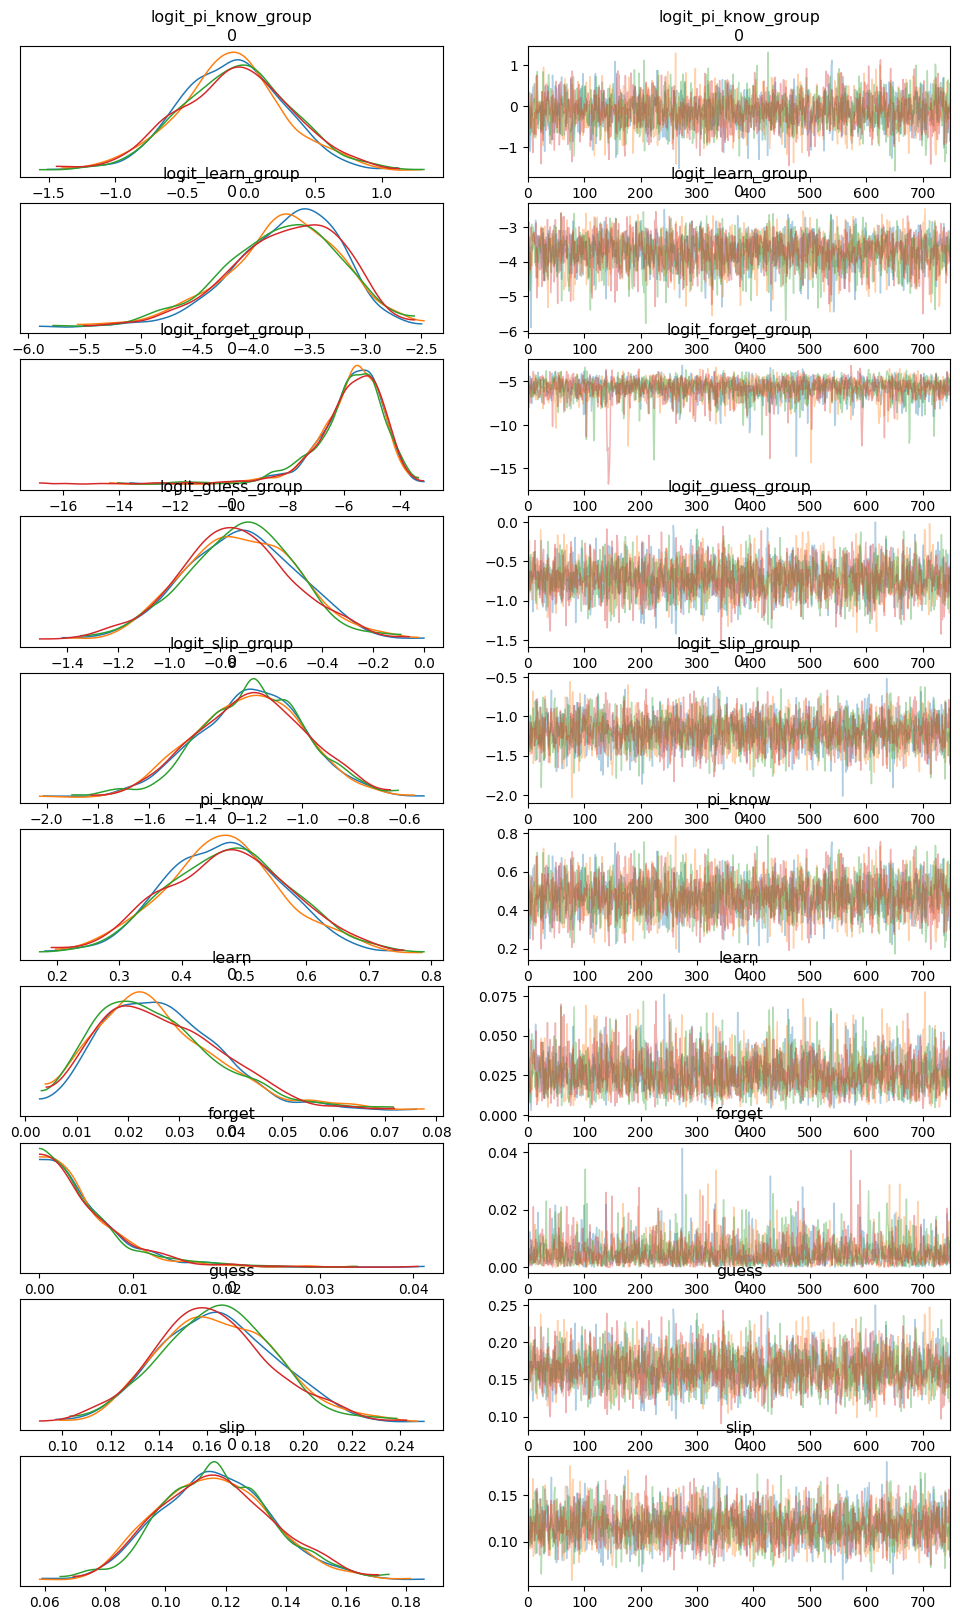

In [ ]:
az.plot_trace(cmdstanpy_data, compact=False, backend='matplotlib')

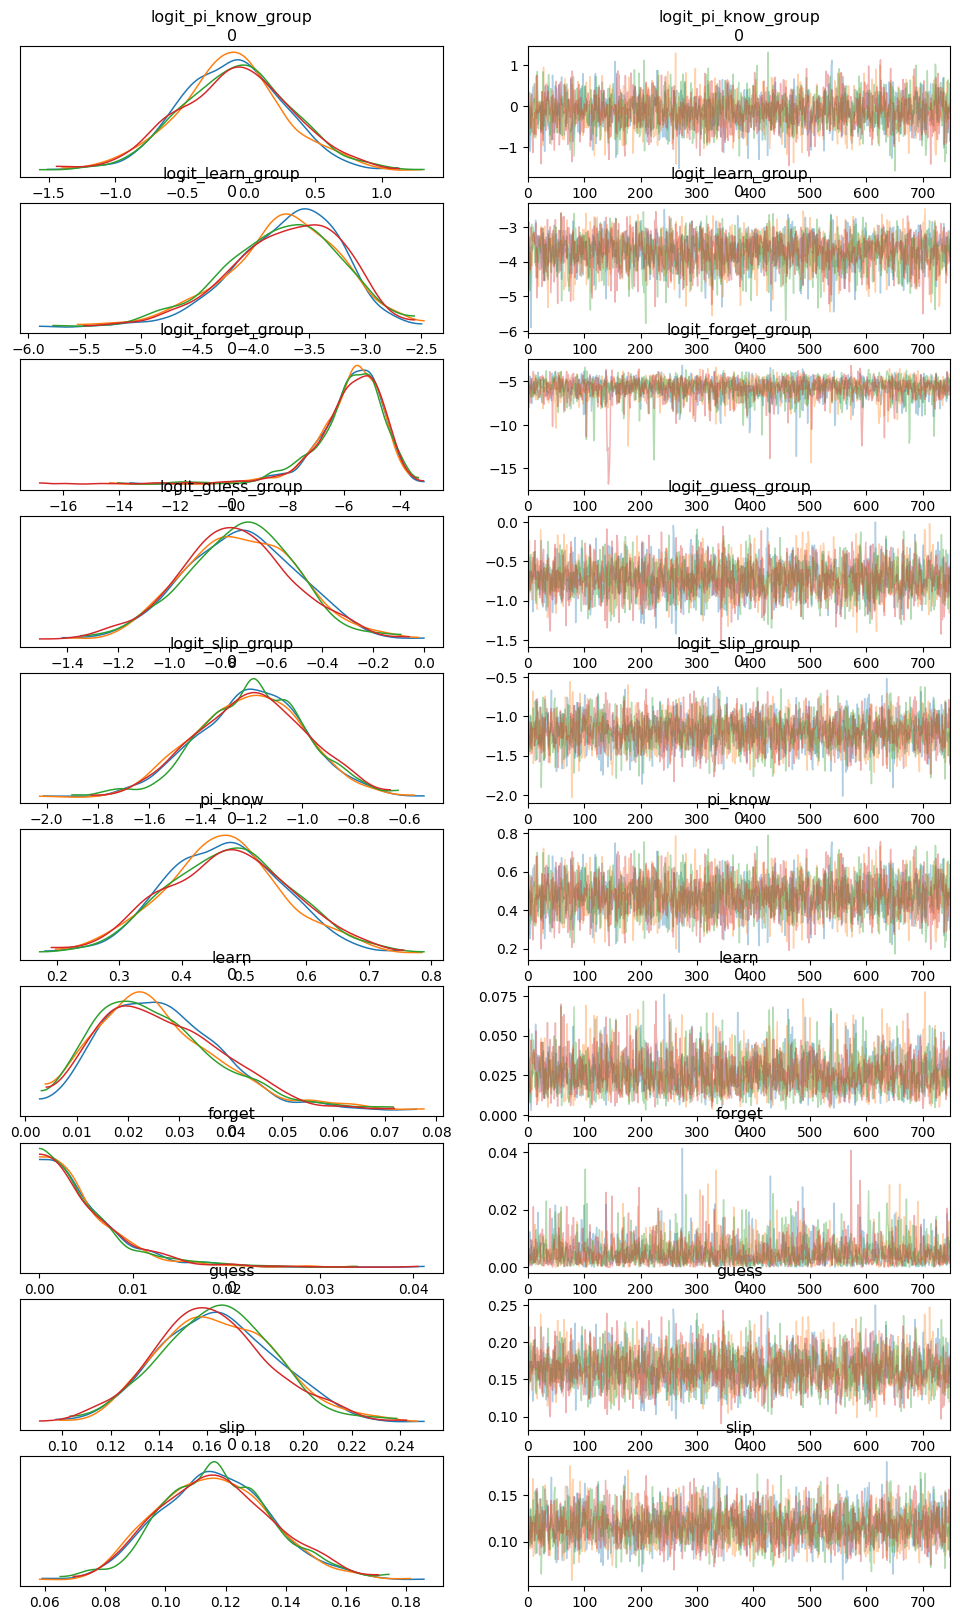

In [67]:
axes = az.plot_trace(cmdstanpy_data, compact=False, backend='matplotlib', show=False)

In [63]:
import matplotlib.pyplot as plt

In [73]:
pickle.dump(cmdstanpy_data, open("test.pkl", "wb"))

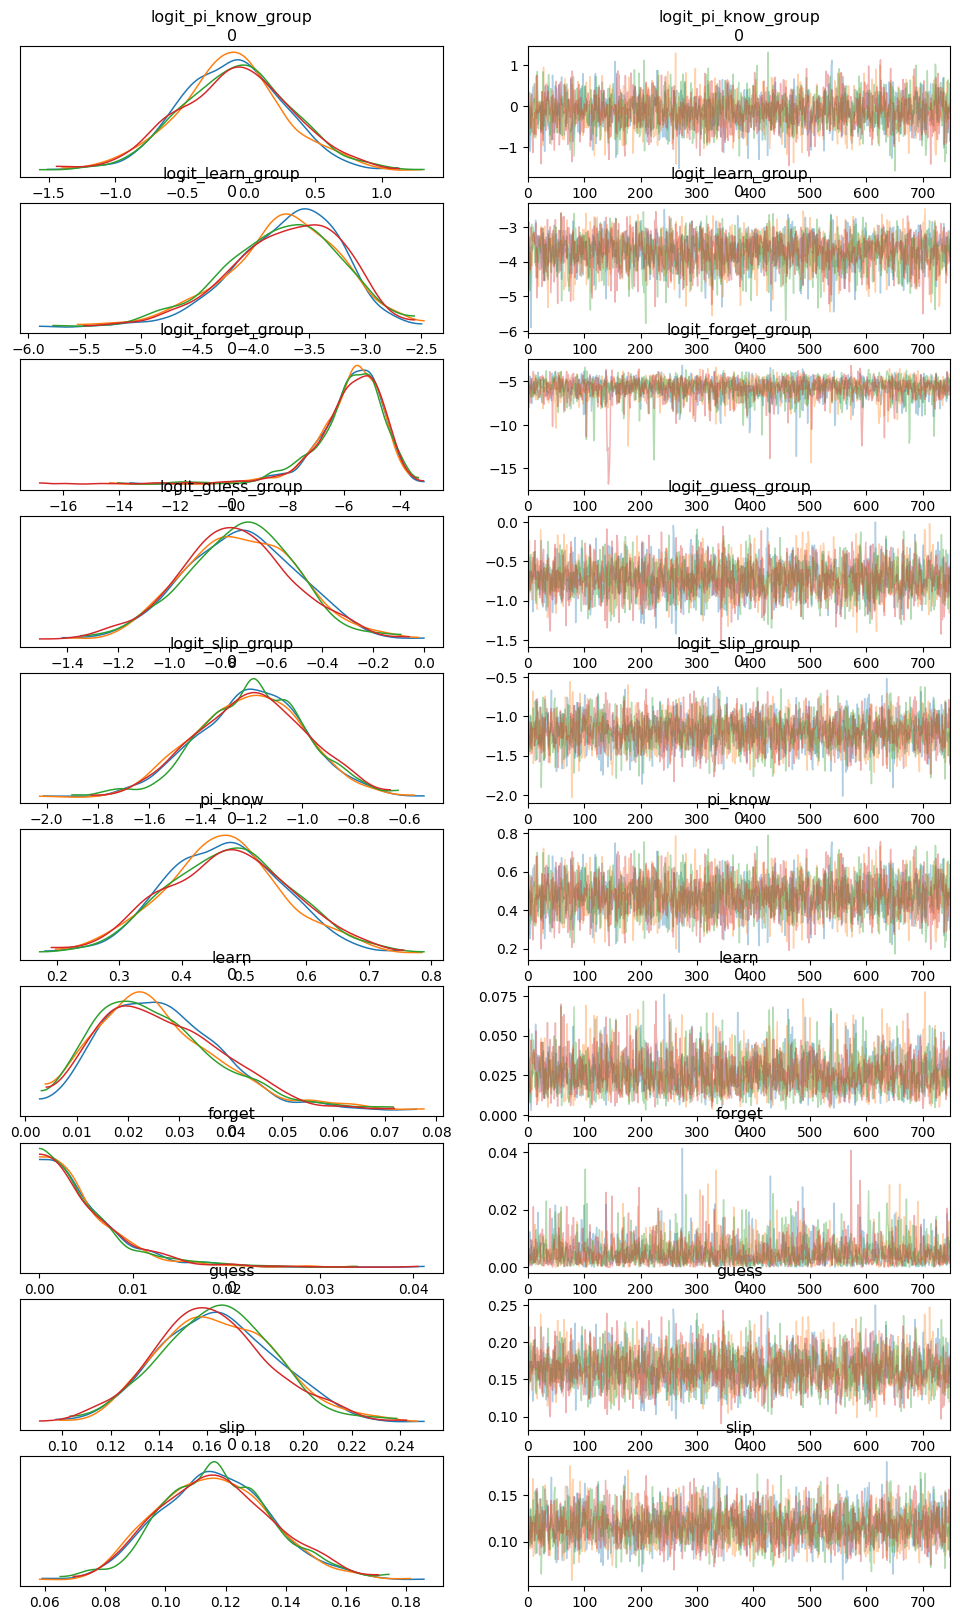

In [ ]:
axes = az.plot_trace(cmdstanpy_data, compact=False, backend='matplotlib', show=True)